In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("data/CIA_Country_Facts.csv")

In [4]:
df.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298
3,American Samoa,OCEANIA,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,15.00,75.00,2.0,22.46,3.27,NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,0.00,97.78,3.0,8.71,6.25,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             227 non-null    object 
 1   Region                              227 non-null    object 
 2   Population                          227 non-null    int64  
 3   Area (sq. mi.)                      227 non-null    int64  
 4   Pop. Density (per sq. mi.)          227 non-null    float64
 5   Coastline (coast/area ratio)        227 non-null    float64
 6   Net migration                       224 non-null    float64
 7   Infant mortality (per 1000 births)  224 non-null    float64
 8   GDP ($ per capita)                  226 non-null    float64
 9   Literacy (%)                        209 non-null    float64
 10  Phones (per 1000)                   223 non-null    float64
 11  Arable (%)                          225 non-n

In [6]:
df.shape

(227, 20)

In [7]:
df = df.fillna(0)

In [8]:
a = df.drop("Country", axis=1)
b = a.drop("Region", axis=1)

In [9]:
b.shape

(227, 18)

In [10]:
x = b["GDP ($ per capita)"]
y = b["Literacy (%)"]

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=325)

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()
scaler.fit(x_train.to_frame())
scaler.fit_transform(x_test.to_frame())

array([[-0.60820438],
       [ 0.14310691],
       [ 2.27778503],
       [-0.50087419],
       [-0.42932074],
       [-0.67975783],
       [-0.78708802],
       [-0.33391613],
       [ 2.2897106 ],
       [-0.56050207],
       [-0.42932074],
       [-0.71553456],
       [ 2.07505023],
       [-0.46509747],
       [ 0.45317189],
       [ 1.38336682],
       [-0.56050207],
       [-0.76323687],
       [ 0.        ],
       [-0.81093917],
       [-0.73938572],
       [-0.73938572],
       [ 0.50087419]])

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
x_train

39      1100.0
199     1000.0
50     10600.0
103    28200.0
194     4900.0
        ...   
110    17800.0
47      5000.0
111    19000.0
73      1700.0
185    13300.0
Name: GDP ($ per capita), Length: 204, dtype: float64

In [17]:
x_train.to_frame().isnull().sum()

GDP ($ per capita)    0
dtype: int64

In [18]:
l1 = LinearRegression()
l1.fit(x_train.to_frame(), y_train.to_frame())

LinearRegression()

In [19]:
y_pred = l1.predict(x_train.to_frame())

In [20]:
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score

In [21]:
y_pred.shape

(204, 1)

In [22]:
median = np.median(y_pred)
pred_binary = (y_pred > median).astype(int)
y_median = np.median(y_train)
y_binary = (y_train > y_median).astype(int)

In [23]:
accuracy = accuracy_score(y_binary, pred_binary)

In [24]:
accuracy*100

70.09803921568627

In [25]:
r2 = r2_score(y_binary, pred_binary)

In [26]:
r2

-0.196078431372549

<Axes: xlabel='GDP ($ per capita)'>

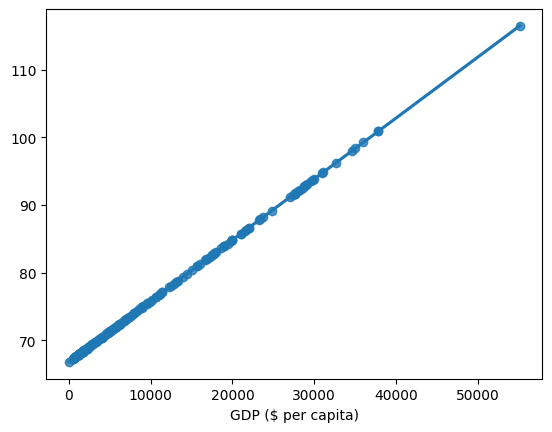

In [27]:
sns.regplot(x=x_train, y=y_pred)

In [28]:
df["Country"]

0         Afghanistan
1             Albania
2             Algeria
3      American Samoa
4             Andorra
            ...      
222         West Bank
223    Western Sahara
224             Yemen
225            Zambia
226          Zimbabwe
Name: Country, Length: 227, dtype: object